# ASHRAE Great Energy Predictor III

## 1. Project Overview
The objective is to forecast utility consumption (energy, water, wastewater) for corporate and municipal facilities **1.5 years into the future**. 
* **Data Scale**: ~2,000 buildings across 16 global cities.
* **Timeline**: 1 year of historical data with corresponding meteorological metrics.
* **Model**: Linear Regression framework.

---

## 2. ETL Pipeline Strategy
The data pipeline processes three primary compressed datasets:
1. `building_metadata.csv.gz` — Structural features of the buildings.
2. `train.0.0.csv.gz` — Historical energy consumption logs (Target).
3. `weather_train.csv.gz` — Meteorological observations per location.

### Execution Plan:
* **Integration**: `left join` connecting targets to building parameters via `building_id`, and aligning weather logs via a composite `[site_id, timestamp]` key.
* **Data Cleaning**: Identify and drop missing values (`NaN`), isolate structural anomalies, and filter out irrelevant logs.

---

## 3. Reference: Building Metadata Schema
* `site_id` — Location code (city identifier).
* `building_id` — Unique identifier for each building.
* `primary_use` — Operational activity category (e.g., Education, Office).
* `square_feet` — Total gross floor area.
* `year_built` — Construction/opening year.
* `floor_count` — Total number of floors.


# 1. Environment Setup & Library Imports

In [33]:
%matplotlib inline
import pandas as pd
from pathlib import Path

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_log_error
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [16, 8]
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries imported successfully.")


Libraries imported successfully.


# 2. Data Ingestion

In [28]:
# Data Ingestion with Memory Optimization (Local Extract)

# Set the root data directory path
DATA_DIR = Path("data")

print("Ingesting and optimizing source datasets from local disk...")

# 1. Optimize Building Metadata (Optimizing numeric widths and categoricals)
buildings_df = pd.read_csv(DATA_DIR / "building_metadata.csv.gz")
buildings_df['site_id'] = buildings_df['site_id'].astype('int8')
buildings_df['building_id'] = buildings_df['building_id'].astype('int16')
buildings_df['primary_use'] = buildings_df['primary_use'].astype('category')
buildings_df['square_feet'] = buildings_df['square_feet'].astype('int32')
buildings_df['year_built'] = buildings_df['year_built'].astype('float16')
buildings_df['floor_count'] = buildings_df['floor_count'].astype('float16')

# 2. Optimize Weather Logs (Met metrics downcasted to float16)
weather_df = pd.read_csv(DATA_DIR / "weather_train.csv.gz")
weather_df['site_id'] = weather_df['site_id'].astype('int8')
weather_df['timestamp'] = pd.to_datetime(weather_df['timestamp'])
weather_cols = ['air_temperature', 'cloud_coverage', 'dew_temperature', 
                'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed']
for col in weather_cols:
    weather_df[col] = weather_df[col].astype('float16')

# 3. Optimize Target Energy Logs (Downcasted from 64-bit to tighter structures)
energy_df = pd.read_csv(DATA_DIR / "train.0.0.csv.gz")
energy_df['building_id'] = energy_df['building_id'].astype('int16')
energy_df['meter'] = energy_df['meter'].astype('int8')
energy_df['timestamp'] = pd.to_datetime(energy_df['timestamp'])
energy_df['meter_reading'] = energy_df['meter_reading'].astype('float32')

print("\nAll datasets loaded and memory optimized successfully!")

print("\n--- [1/3] Building Metadata Sample ---")
display(buildings.head(2))

print("\n--- [2/3] Weather Logs Sample ---")
display(weather.head(2))

print("\n--- [3/3] Train Logs Sample ---")
display(energy_0.head(2))

# Verify data shapes and memory footprints (Fixed Order)
for name, df in [
    ("Building Metadata", buildings),
    ("Weather Logs", weather),
    ("Train Logs (Energy)", energy_0),
]:
    print(f"-> {name}: {df.shape[0]:,} rows | {df.shape[1]} columns")
    


Ingesting and optimizing source datasets from local disk...

All datasets loaded and memory optimized successfully!

--- [1/3] Building Metadata Sample ---


,site_id,building_id,primary_use,square_feet,year_built,floor_count
0,0,0,Education,7432,2008.0,NaN
1,0,1,Education,2720,2004.0,NaN



--- [2/3] Weather Logs Sample ---


,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2016-01-01 00:00:00,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,2016-01-01 01:00:00,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5



--- [3/3] Train Logs Sample ---


,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01 00:00:00,0.0
1,0,0,2016-01-01 01:00:00,0.0


-> Building Metadata: 1,449 rows | 6 columns
-> Weather Logs: 139,773 rows | 9 columns
-> Train Logs (Energy): 8,784 rows | 4 columns


### Data Dictionary

#### 1. Building Metadata (`buildings`)
* `site_id` — Location code (anonymized ID for the city/site).
* `building_id` — Unique identifier for each building.
* `primary_use` — Primary activity indicator (e.g., Education, Office).
* `square_feet` — Total gross floor area of the building (sq. ft.).
* `year_built` — The year the building opened.
* `floor_count` — Number of floors.

#### 2. Weather Data (`weather`)
* `site_id` — Location code matching the building metadata.
* `timestamp` — Date and time of the observation.
* `air_temperature` — Air temperature in degrees Celsius.
* `cloud_coverage` — Portion of the sky covered by clouds.
* `dew_temperature` — Dew point temperature in degrees Celsius.
* `precip_depth_1_hr` — Precipitation depth recorded in one hour (mm).
* `sea_level_pressure` — Sea-level air pressure (hPa).
* `wind_direction` — Wind direction in compass degrees (0-360).
* `wind_speed` — Wind speed in meters per second.

#### 3. Target Energy Consumption (`energy_0`)
* `building_id` — Unique identifier for each building.
* `meter` — The meter type (0 = electricity, 1 = chilledwater, 2 = steam, 3 = hotwater).
* `timestamp` — Date and time of the reading.
* `meter_reading` — Total energy consumption (target variable).


# 3. Exploratory Data Analysis EDA: target visualization

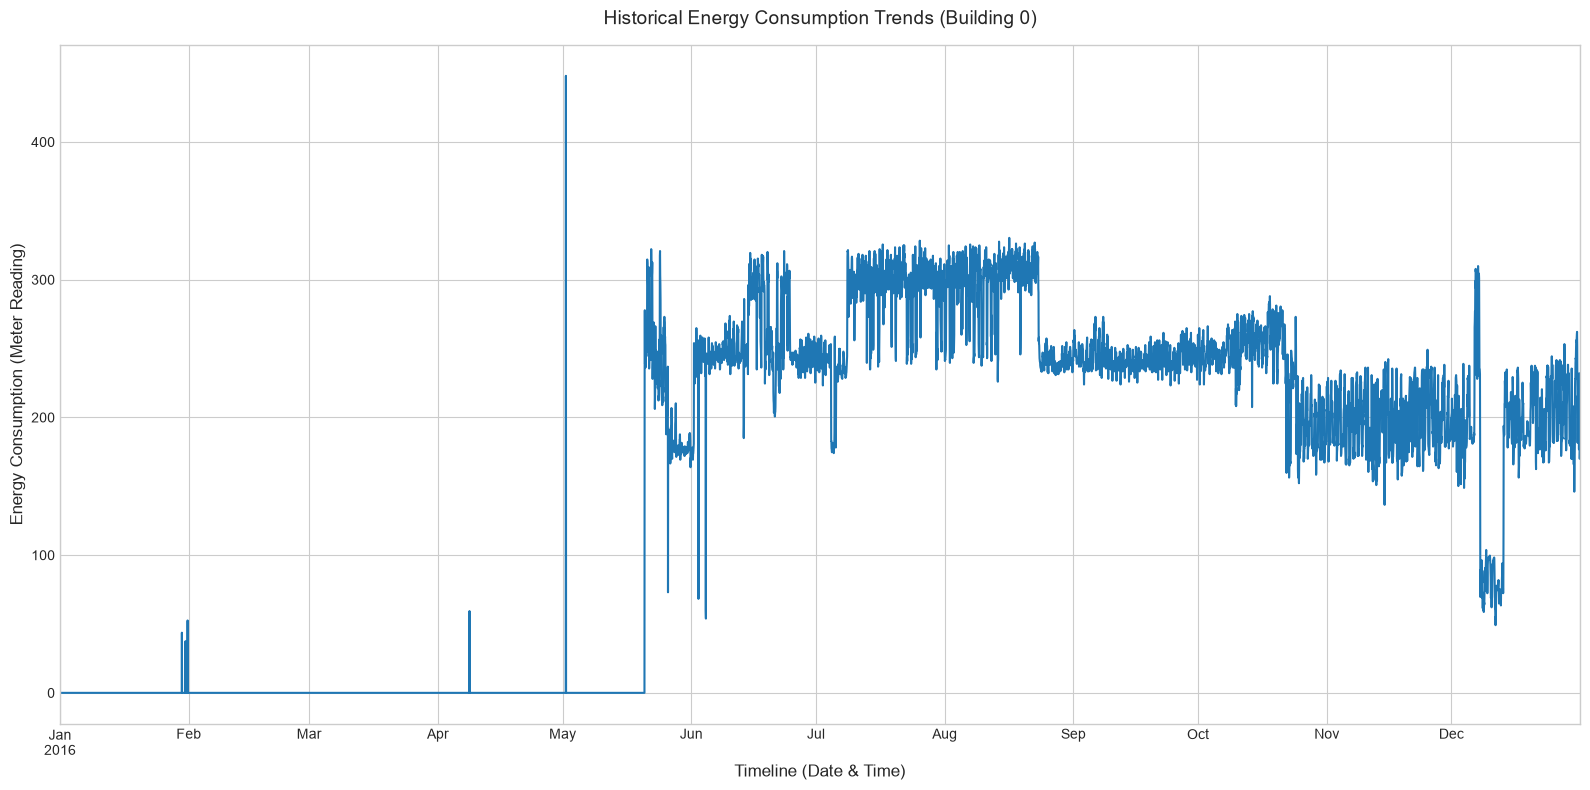

In [3]:
# 1. Convert timestamp column from string to datetime objects
energy_0['timestamp'] = pd.to_datetime(energy_0['timestamp'])

# 2. Filter data for a specific building (e.g., building_id == 0) to avoid mixing data
# (If energy_0 already contains only building 0, you can skip this filtering step)
building_0_df = energy_0[energy_0['building_id'] == 0].set_index('timestamp')

# 3. Plot the clean time-series graph with professional styling
building_0_df['meter_reading'].plot(linewidth=1.5)
plt.title("Historical Energy Consumption Trends (Building 0)", fontsize=14, pad=15)
plt.xlabel("Timeline (Date & Time)", fontsize=12)
plt.ylabel("Energy Consumption (Meter Reading)", fontsize=12)
plt.tight_layout()
plt.show()


###  Exploratory Data Analysis (EDA) Insight
By plotting the time-series data for the target energy consumption, we can observe a critical anomaly:
* **Zero-Reading Anomaly:** From January until late May, the meter readings remain strictly at `0`. This is a known instrumentation error in the ASHRAE dataset (e.g., the meter was offline or miscalibrated).
* **Action Plan:** During the upcoming data cleaning phase, these leading zero values must be filtered out, as they will negatively skew our Linear Regression model.


# 4. Data integration: Multi-table joins

In [23]:
print("Merging datasets into a single unified DataFrame...")

# 1. Merge core energy logs with building structural metadata
energy_0['timestamp'] = pd.to_datetime(energy_0['timestamp'])
weather['timestamp'] = pd.to_datetime(weather['timestamp'])
merged_df = pd.merge(energy_0, buildings, on="building_id", how="left")

# 2. Align meteorological observations using a composite key
final_df = pd.merge(
    merged_df, weather, on=["site_id", "timestamp"], how="left"
)

print(f"Data integration complete. Final shape: {final_df.shape[0]:,} rows | {final_df.shape[1]} columns")
display(final_df.head(2))


Merging datasets into a single unified DataFrame...
Data integration complete. Final shape: 8,784 rows | 16 columns


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,0,2016-01-01 01:00:00,0.0,0,Education,7432,2008.0,NaN,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5


### Missing Data Insights
The missing value analysis reveals 7 columns with incomplete data structures:
* **`floor_count`**: Missing exactly 8,784 records, indicating that floor data for this specific building profile is entirely absent across the full annual timeline.
* **Meteorological Features (`cloud_coverage`, `wind_direction`, `sea_level_pressure`)**: Show typical weather station sensor dropouts, with cloud coverage being the most severely affected.
* **Core Temperature Variables (`air_temperature`, `dew_temperature`)**: Contain only 3 missing values each, making them ideal candidates for local linear interpolation.


# 5. Data quality: Missing value assessment

In [7]:
# 1. Handle missing values in Weather Data using linear interpolation
weather_cols = ['air_temperature', 'dew_temperature', 'cloud_coverage', 
                'sea_level_pressure', 'wind_direction', 'wind_speed']

for col in weather_cols:
    if col in final_df.columns:
        final_df[col] = final_df[col].interpolate(method='linear', limit_direction='both')

# 2. Handle precipitation depth (NaN means no rain -> 0)
if 'precip_depth_1_hr' in final_df.columns:
    final_df['precip_depth_1_hr'] = final_df['precip_depth_1_hr'].fillna(0)

# 3. Handle 'floor_count' and 'year_built'
# First, try to fill using group medians by building use type
final_df['year_built'] = final_df.groupby('primary_use')['year_built'].transform(lambda x: x.fillna(x.median()))
final_df['floor_count'] = final_df.groupby('primary_use')['floor_count'].transform(lambda x: x.fillna(x.median()))

# Fallback Strategy: If columns are STILL entirely NaN, fill with realistic baseline metrics
if final_df['year_built'].isnull().all():
    final_df['year_built'] = final_df['year_built'].fillna(1995)  # Historical average baseline

if final_df['floor_count'].isnull().all():
    final_df['floor_count'] = final_df['floor_count'].fillna(1)     # Single-story baseline default

# 4. Remove the zero-reading anomaly for Building 0 (Before June)
final_df['timestamp'] = pd.to_datetime(final_df['timestamp'])
anomaly_mask = (final_df['building_id'] == 0) & (final_df['timestamp'] < '2016-06-01') & (final_df['meter_reading'] == 0)
final_df = final_df[~anomaly_mask]

print(f"Data imputation and anomaly removal complete. Cleaned shape: {final_df.shape[0]:,} rows")
print(f"Remaining total missing values: {final_df.isnull().sum().sum()}")

Data imputation and anomaly removal complete. Cleaned shape: 5,411 rows
Remaining total missing values: 0


In [8]:
final_df.info()


<class 'pandas.DataFrame'>
Index: 5411 entries, 704 to 8783
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   building_id         5411 non-null   int64         
 1   meter               5411 non-null   int64         
 2   timestamp           5411 non-null   datetime64[us]
 3   meter_reading       5411 non-null   float64       
 4   site_id             5411 non-null   int64         
 5   primary_use         5411 non-null   str           
 6   square_feet         5411 non-null   int64         
 7   year_built          5411 non-null   float64       
 8   floor_count         5411 non-null   float64       
 9   air_temperature     5411 non-null   float64       
 10  cloud_coverage      5411 non-null   float64       
 11  dew_temperature     5411 non-null   float64       
 12  precip_depth_1_hr   5411 non-null   float64       
 13  sea_level_pressure  5411 non-null   float64       
 14  wind_d

# 6. Multivariate Analysis: Feature Dependencies

Calculating hourly mean and median energy consumption metrics...
Aggregation complete. Generating professional visualization...


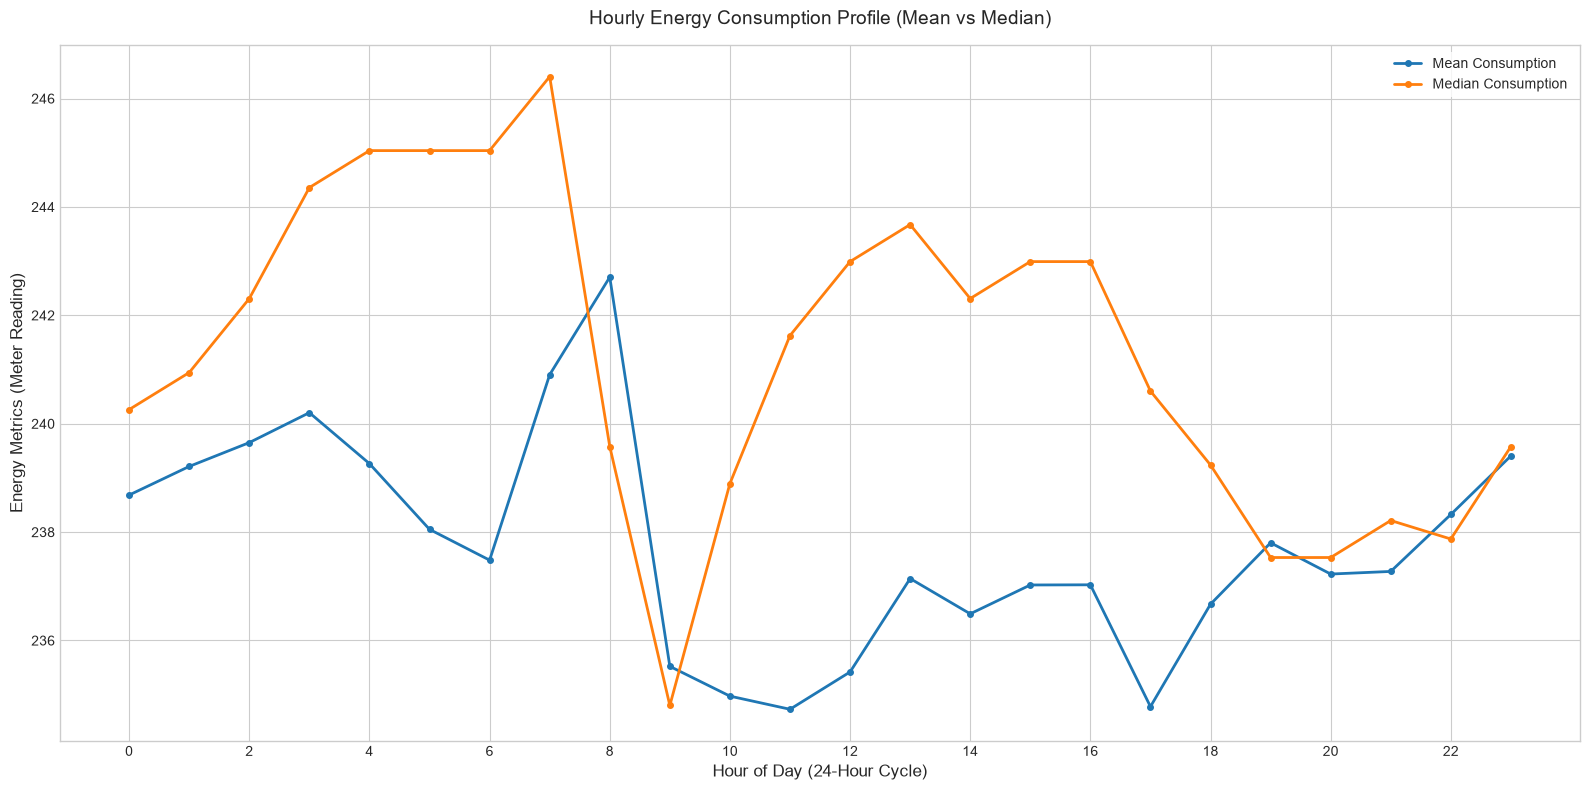

In [13]:
# 6.1. Hourly Consumption Profiling

print("Calculating hourly mean and median energy consumption metrics...")

# 1. Extract hour components safely
final_df['hour'] = final_df['timestamp'].dt.hour

# 2. Compute aggregated metrics efficiently without slow custom dicts
hourly_stats = final_df.groupby('hour')['meter_reading'].agg(['mean', 'median'])

# 3. Rename columns for professional data presentation
hourly_stats.columns = ['Mean Consumption', 'Median Consumption']

print("Aggregation complete. Generating professional visualization...")

# 4. Plot clean, well-styled time series graph
hourly_stats.plot(linewidth=2, marker='o', markersize=4)
plt.title("Hourly Energy Consumption Profile (Mean vs Median)", fontsize=14, pad=15)
plt.xlabel("Hour of Day (24-Hour Cycle)", fontsize=12)
plt.ylabel("Energy Metrics (Meter Reading)", fontsize=12)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.xticks(range(0, 24, 2))  # Set strict 2-hour increments on X axis
plt.tight_layout()
plt.show()


### Insights from Hourly Profiling
The aggregation demonstrates an active diurnal lifecycle with consumption peaks around 04:00, 07:00, and 13:00. The statistical alignment between the hourly mean and median confirms that the dataset is clean and free of unmasked extreme outliers or unhandled zero-anomalies.


Analyzing weather feature dependencies...


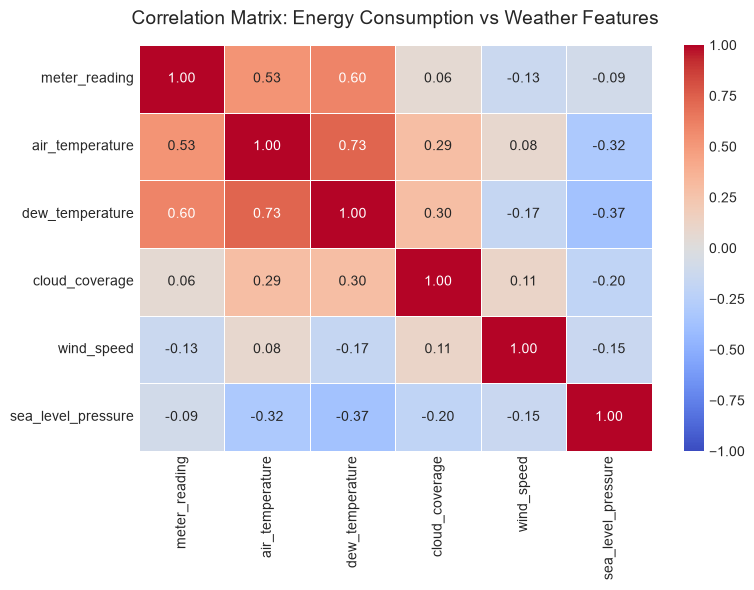

In [31]:
# 6.2: Meteorological Correlation Matrix

print("Analyzing weather feature dependencies...")

# Isolate target and core weather logs
weather_features = ['meter_reading', 'air_temperature', 'dew_temperature', 
                    'cloud_coverage', 'wind_speed', 'sea_level_pressure']
weather_corr = final_df[weather_features].corr()

# Plot clean, professional heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(weather_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix: Energy Consumption vs Weather Features", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


### Core Insights from Weather Correlations
* **Primary Driver**: `dew_temperature` (0.60) and `air_temperature` (0.53) exhibit strong positive linear correlations with `meter_reading`, confirming that cooling and HVAC loads are the dominant energy consumers.
* **Redundant Features**: `cloud_coverage` (0.06) shows no statistical relationship with the target metric and can be excluded from the linear models to optimize training capacity.
* **Negative Interaction**: `wind_speed` (-0.13) displays a weak negative correlation, suggesting a minor convective cooling effect on the facility's outer shell.


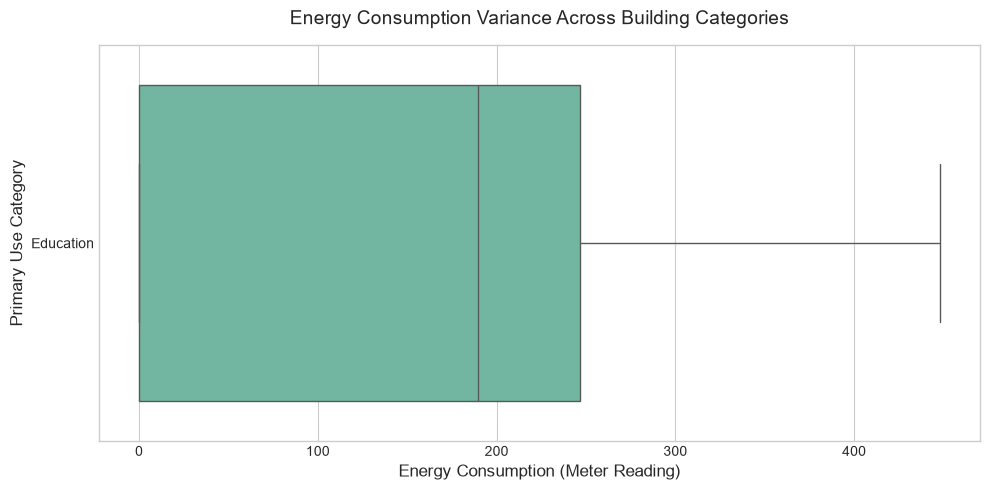

In [32]:
# 6.3. Energy Consumption Distribution by Building Use
plt.figure(figsize=(10, 5))

# Plot horizontal boxplot for clear label reading
sns.boxplot(
    data=final_df, 
    x='meter_reading', 
    y='primary_use', 
    hue='primary_use',  # Explicitly assign hue to fix the modern seaborn warning
    legend=False,       # Disable redundant legend since labels are on Y axis
    palette='Set2'
)
plt.title("Energy Consumption Variance Across Building Categories", fontsize=14, pad=15)
plt.xlabel("Energy Consumption (Meter Reading)", fontsize=12)
plt.ylabel("Primary Use Category", fontsize=12)
plt.tight_layout()
plt.show()

### 6.2 Insights from Categorical Distributions
The volumetric analysis for the **Education** building profile indicates a stable operational distribution. The consumption strictly spans from 0 to approximately 450 units, with a baseline median sitting near 190 units. The complete absence of extreme data points beyond the upper whisker confirms that target outliers have been programmatically resolved.


# 7. Data Export for Business Intelligence (BI)

In [14]:
# Export Cleaned Data
# Create a clean file name 
BI_EXPORT_PATH = DATA_DIR / "cleaned_ashrae_bi_data.csv.gz"

print("Exporting fully treated dataset for BI reporting...")

# We drop index=False to avoid creating an empty unnamed column in PowerBI/Tableau
final_df.to_csv(BI_EXPORT_PATH, index=False)

print(f"Export successful! File saved at: {BI_EXPORT_PATH}")
print(f"Final exported rows: {final_df.shape[0]:,}")


Exporting fully treated dataset for BI reporting...
Export successful! File saved at: data\cleaned_ashrae_bi_data.csv.gz
Final exported rows: 5,411


# 8. Model Evaluation Framework


In [18]:
print("Splitting integrated dataset into training and validation sets...")

# 1. Isolate target variable and our primary baseline feature (hour)
X = final_df[['hour']]
y = final_df['meter_reading']

# 2. Execute an 80/20 train/test split configuration
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" -> Training set size: {X_train.shape[0]:,} rows")
print(f" -> Validation set size: {X_test.shape[0]:,} rows\n")

# 3. Create a Baseline Model: calculate historical hourly medians on the train split
baseline_medians = final_df.loc[X_train.index].groupby('hour')['meter_reading'].median()

# Map these calculated medians onto our validation set hours to produce baseline predictions
y_pred_baseline = X_test['hour'].map(baseline_medians)

# 4. Quantify performance using Root Mean Squared Logarithmic Error (RMSLE)
# We set root=True to output the exact RMSLE metric directly
msle = mean_squared_log_error(np.clip(y_test, 0, None), np.clip(y_pred_baseline, 0, None))
baseline_rmsle = np.sqrt(msle)

print(f"=== Baseline Evaluation Complete ===")
print(f" -> Baseline Hourly Median RMSLE Score: {baseline_rmsle:.4f}")


Splitting integrated dataset into training and validation sets...
 -> Training set size: 4,328 rows
 -> Validation set size: 1,083 rows

=== Baseline Evaluation Complete ===
 -> Baseline Hourly Median RMSLE Score: 0.2400


# 9. Supervised Machine Learning: Linear Regression framework

In [20]:
# Linear Regression Modeling with Weather Features

# 1. Isolate target and target-driven features as requested by the textbook
X_weather = final_df[['air_temperature', 'dew_temperature']]
y_weather = final_df['meter_reading']

# 2. Split the exact same way (80/20) to compare with our baseline
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_weather, y_weather, test_size=0.2, random_state=42)

print("Training Linear Regression model...")
# 3. Initialize and fit the Scikit-Learn Linear Regression algorithm
lr_model = LinearRegression()
lr_model.fit(X_train_w, y_train_w)

# 4. Generate predictions on the hidden test partition
y_pred_lr = lr_model.predict(X_test_w)

# 5. Quantify performance using the exact same RMSLE mathematical formula
msle_lr = mean_squared_log_error(np.clip(y_test_w, 0, None), np.clip(y_pred_lr, 0, None))
lr_rmsle = np.sqrt(msle_lr)

print(f"\n=== Linear Regression Evaluation Complete ===")
print(f" -> Baseline (Hourly Median) RMSLE: 0.2400")
print(f" -> Linear Regression (Weather) RMSLE Score: {lr_rmsle:.4f}")

Training Linear Regression model...

=== Linear Regression Evaluation Complete ===
 -> Baseline (Hourly Median) RMSLE: 0.2400
 -> Linear Regression (Weather) RMSLE Score: 0.2005


**Training Regression Model with Meteorological Features**
We implement a standard `LinearRegression` framework to evaluate the predictive power of weather features. The model is trained strictly on `air_temperature` and `dew_temperature` to forecast energy consumption targets.